# 02. MDS, Isomap, t-SNE i UMAP — od macierzy do embeddingu

**Czas podstawowy:** około 75–90 minut  
**Sekcje oznaczone „Dodatkowe” można dokończyć po zajęciach.**

## Cel wspólny

Chcemy zamienić punkty:

$$
X\in\mathbb{R}^{n\times p}
$$

na współrzędne:

$$
Y\in\mathbb{R}^{n\times 2},
$$

tak aby na rysunku zachować możliwie dużo istotnej struktury danych.

Metody różnią się przede wszystkim tym, **co uznają za strukturę do zachowania**:

| Metoda | Obiekt z danych wejściowych | Obiekt w 2D | Funkcja celu |
|---|---|---|---|
| MDS | macierz odległości $D^X$ | macierz odległości $D^Y$ | stress |
| Isomap | odległości grafowe $D^G$ | macierz odległości $D^Y$ | MDS na $D^G$ |
| t-SNE | rozkład podobieństw $P$ | rozkład podobieństw $Q(Y)$ | $KL(P\|Q)$ |
| UMAP | ważony fuzzy graf $P$ | fuzzy graf $Q(Y)$ | fuzzy cross-entropy |

W każdym przypadku optymalizowane są współrzędne $Y$, ale **target** budowany z $X$ pozostaje stały.

## 0. Słownik macierzy

$$
X
\longrightarrow
D^X
\longrightarrow
A_\varepsilon/A_{kNN}
\longrightarrow
W
\longrightarrow
P
$$

oraz po stronie embeddingu:

$$
Y
\longrightarrow
D^Y
\longrightarrow
Q(Y).
$$

| Symbol | Znaczenie |
|---|---|
| $D^X$ | odległości w danych wejściowych |
| $A_\varepsilon$, $A_{kNN}$ | binarne sąsiedztwo |
| $W$ | lokalne, ważone podobieństwa |
| $P$ | relacje docelowe zbudowane z $X$ |
| $D^Y$ | odległości w aktualnym embeddingu |
| $Q(Y)$ | relacje odtworzone przez aktualne $Y$ |

> Reguła pamięciowa: **$P$ pochodzi z danych i mówi, co chcemy zachować. $Q$ pochodzi z mapy i mówi, co obecnie udało się odtworzyć.**

In [32]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import make_s_curve, make_moons
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness, SpectralEmbedding
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
from scipy.stats import spearmanr

RANDOM_STATE = 42
EPS = 1e-12
np.set_printoptions(precision=3, suppress=True)

def show_matrix(M, labels=None, title=None, vmin=None, vmax=None):
    labels = labels if labels is not None else list(range(len(M)))
    plt.figure(figsize=(5.4, 4.5))
    im = plt.imshow(M, vmin=vmin, vmax=vmax)
    plt.colorbar(im)
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    if len(M) <= 12:
        for i in range(len(M)):
            for j in range(len(M)):
                plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)
    if title:
        plt.title(title)
    plt.show()

def normalized_stress(D_target, D_embedding):
    tri = np.triu_indices_from(D_target, k=1)
    numerator = np.sum((D_target[tri] - D_embedding[tri]) ** 2)
    denominator = np.sum(D_target[tri] ** 2)
    return np.sqrt(numerator / denominator)

def distance_spearman(D1, D2):
    tri = np.triu_indices_from(D1, k=1)
    return spearmanr(D1[tri], D2[tri]).statistic

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False


## 1. Dane demonstracyjne: powierzchnia typu S ukryta w 10 wymiarach

Najpierw generujemy klasyczną powierzchnię typu S w 3D. Następnie wykonujemy losową projekcję do 10 wymiarów i dodajemy niewielki szum. **Algorytmy redukcji otrzymują macierz $X\in\mathbb{R}^{n\times 10}$**, a rysunek 3D służy jedynie do zrozumienia ukrytej geometrii.

Na zakrzywionej powierzchni dwa punkty mogą:

- być blisko w przestrzeni euklidesowej przez „skrót” przecinający zwój,
- być daleko, gdy mierzymy drogę po samej powierzchni.

Porównamy:

- **PCA** — liniową projekcję,
- **MDS** — odtwarzanie pełnej macierzy odległości euklidesowych,
- **Isomap** — MDS na odległościach po grafie $kNN$,
- **Laplacian Eigenmaps** — embedding sterowany lokalnym grafem,
- **t-SNE** — porównanie rozkładów podobieństw $P$ i $Q$,
- **UMAP** — porównanie rozmytych grafów $P$ i $Q$.

Kolor oznacza położenie wzdłuż zakrzywionego kierunku. Dobre „rozwinięcie” powinno zachować płynny przebieg kolorów i lokalnych sąsiadów.


Kształt danych wejściowych dla algorytmów: (180, 10)


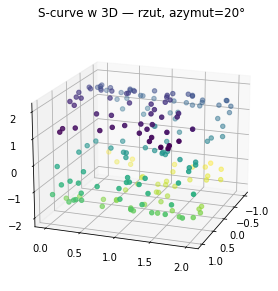

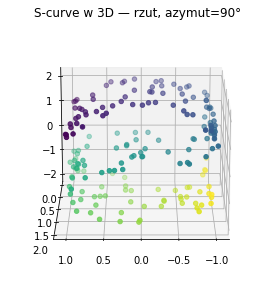

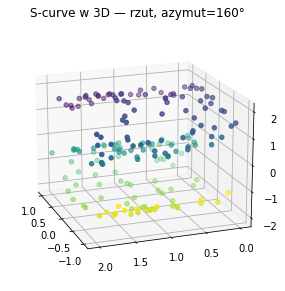

In [33]:
X_curve_3d, curve_position = make_s_curve(
    n_samples=180,
    noise=0.025,
    random_state=RANDOM_STATE,
)

# Ukryta współrzędna wewnętrzna powierzchni: pozycja wzdłuż S oraz wysokość.
intrinsic_curve = np.column_stack([curve_position, X_curve_3d[:, 1]])
intrinsic_curve_scaled = StandardScaler().fit_transform(intrinsic_curve)
D_intrinsic = pairwise_distances(intrinsic_curve_scaled)

# Algorytmy dostają nie 3, lecz 10 wymiarów.
rng_curve = np.random.default_rng(RANDOM_STATE)
projection_10x3, _ = np.linalg.qr(rng_curve.normal(size=(10, 3)))
X_curve = X_curve_3d @ projection_10x3.T
X_curve += 0.015 * rng_curve.normal(size=X_curve.shape)
D_curve = pairwise_distances(X_curve)

print("Kształt danych wejściowych dla algorytmów:", X_curve.shape)

# Kilka statycznych rzutów — pomaga zobaczyć, że jest to rzeczywiście powierzchnia S.
for azimuth in [20, 90, 160]:
    fig = plt.figure(figsize=(6.2, 4.8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(
        X_curve_3d[:, 0], X_curve_3d[:, 1], X_curve_3d[:, 2],
        c=curve_position, s=20,
    )
    ax.view_init(elev=18, azim=azimuth)
    ax.set_title(f"S-curve w 3D — rzut, azymut={azimuth}°")
    plt.show()

# Wersja interaktywna: przeciągnij myszą, aby obrócić powierzchnię.
if PLOTLY_AVAILABLE:
    plotly_data = pd.DataFrame({
        "x": X_curve_3d[:, 0],
        "y": X_curve_3d[:, 1],
        "z": X_curve_3d[:, 2],
        "pozycja_na_S": curve_position,
    })
    fig_s = px.scatter_3d(
        plotly_data,
        x="x", y="y", z="z",
        color="pozycja_na_S",
        title="Interaktywna powierzchnia S — obróć wykres myszą",
    )
    fig_s.update_traces(marker={"size": 3})
    fig_s.show()
else:
    print("Brak plotly. Instalacja opcjonalna: pip install plotly")


# Część A — MDS i metody spektralne

## 2. MDS: używana macierz to $D^X$

MDS zaczyna od pełnej macierzy odległości:

$$
D^X=[d^X_{ij}].
$$

Dla aktualnego embeddingu $Y$ wyznaczamy:

$$
D^Y_{ij}=\lVert y_i-y_j\rVert.
$$

Wariant metryczny można opisać funkcją stress:

$$
\operatorname{Stress}(Y)
=
\sqrt{
\frac{
\sum_{i<j}(d^X_{ij}-d^Y_{ij})^2
}{
\sum_{i<j}(d^X_{ij})^2
}
}.
$$

Im mniejszy stress, tym wierniej odtworzono odległości.

### Klasyczny MDS

Klasyczny MDS wykonuje algebraiczne przejście:

$$
B=-\frac12 J(D^X)^{\circ 2}J,
\qquad
J=I-\frac1n\mathbf 1\mathbf 1^T.
$$

Następnie:

$$
B=V\Lambda V^T,
\qquad
Y=V_2\Lambda_2^{1/2}.
$$

Ściśle rzecz biorąc, klasyczny MDS optymalizuje kryterium związane z iloczynami skalarnymi („strain”), ale wynik oceniamy również przez odtworzenie $D^X$.

### Co zachowuje?

MDS wykorzystuje **wszystkie pary**, dlatego jest bardziej globalny niż t-SNE i UMAP.

### `TODO 1` — zaimplementuj klasyczny MDS

### Pseudokod

```text
n = liczba punktów
J = I - macierz_jedynek / n
B = -0.5 * J @ (D**2) @ J
wartości, wektory = eigh(B)
posortuj malejąco
wybierz dodatnie wartości dla dwóch wymiarów
Y = wektory * sqrt(wartości)
```

### Pseudokod bliski Pythonowi

```python
n = D.shape[0]
J = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * J @ (D ** 2) @ J

eigenvalues, eigenvectors = np.linalg.eigh(B)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

positive_values = np.maximum(eigenvalues[:n_components], 0)
Y = eigenvectors[:, :n_components] * np.sqrt(positive_values)
```


In [34]:
def classical_mds(D, n_components=2):
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigenvalues, eigenvectors = np.linalg.eigh(B)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    selected = np.clip(eigenvalues[:n_components], 0, None)
    Y = eigenvectors[:, :n_components] * np.sqrt(selected)
    return Y, eigenvalues, B

normalized_stress             0.137
Spearman(D_X, D_Y)            0.967
Spearman(D_intrinsic, D_Y)    0.589
trustworthiness_k10           0.951
dtype: float64

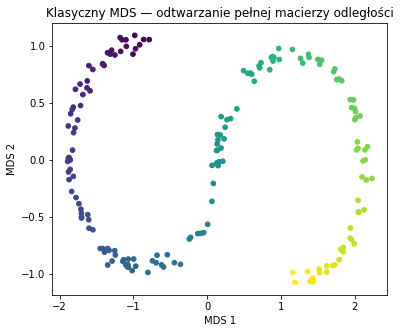

In [35]:
Y_mds, eigenvalues_mds, B_mds = classical_mds(D_curve, n_components=2)

assert Y_mds is not None, "Uzupełnij TODO 1."
assert Y_mds.shape == (len(X_curve), 2)
assert np.isfinite(Y_mds).all()
assert np.allclose(B_mds, B_mds.T)

D_mds = pairwise_distances(Y_mds)

mds_metrics = {
    "normalized_stress": normalized_stress(D_curve, D_mds),
    "Spearman(D_X, D_Y)": distance_spearman(D_curve, D_mds),
    "Spearman(D_intrinsic, D_Y)": distance_spearman(D_intrinsic, D_mds),
    "trustworthiness_k10": trustworthiness(X_curve, Y_mds, n_neighbors=10),
}
display(pd.Series(mds_metrics).round(3))

plt.figure(figsize=(6, 5))
plt.scatter(Y_mds[:, 0], Y_mds[:, 1], c=curve_position, s=22)
plt.title("Klasyczny MDS — odtwarzanie pełnej macierzy odległości")
plt.xlabel("MDS 1")
plt.ylabel("MDS 2")
plt.show()

### Dlaczego MDS może nie „rozwinąć” S-curve?

Odległość euklidesowa pomiędzy punktami na dwóch fragmentach zakrzywionej powierzchni może przecinać przestrzeń na skróty. MDS wiernie pracuje na dostarczonym $D^X$; jeśli ta macierz nie opisuje odległości „po powierzchni”, metoda sama tego nie naprawi.

To prowadzi bezpośrednio do Isomap.

## 3. Isomap: $A_{kNN}\rightarrow D^G\rightarrow$ MDS

Isomap jest najprostszym pomostem od znanych już macierzy sąsiedztwa do redukcji wymiarowości.

1. Liczymy $D^X$.
2. Budujemy graf $kNN$.
3. Wagi krawędzi są równe odległościom $D^X_{ij}$.
4. Liczymy najkrótsze ścieżki:

$$
D^G_{ij}=\text{długość najkrótszej ścieżki }i\to j.
$$

5. Uruchamiamy MDS na $D^G$.

$$
X\to D^X\to A_{kNN}\to D^G\to \text{MDS}\to Y.
$$

$D^G$ ma przybliżać odległość geodezyjną po strukturze danych.

### `TODO 2` — zbuduj ważony graf kNN i macierz odległości grafowych

### Pseudokod

```text
utwórz W_graph wypełnione zerami
dla każdego punktu i:
    wybierz k najbliższych punktów
    wpisz do W_graph[i,j] odległość D_curve[i,j]
symetryzuj graf przez union
policz shortest_path na grafie
sprawdź, czy wszystkie odległości są skończone
```

### Pseudokod bliski Pythonowi

```python
for i in range(len(D_curve)):
    order = np.argsort(D_curve[i])
    neighbors = order[order != i][:k_isomap]
    W_graph[i, neighbors] = D_curve[i, neighbors]

# union: zachowaj krawędź, jeżeli pojawiła się w dowolnym kierunku
W_graph = np.maximum(W_graph, W_graph.T)
D_geodesic = shortest_path(csr_matrix(W_graph), directed=False)
```


In [36]:
k_isomap = 10
W_graph = np.zeros_like(D_curve)

for i in range(len(D_curve)):
    order = np.argsort(D_curve[i])
    neighbors = order[1:k_isomap + 1]
    W_graph[i, neighbors] = D_curve[i, neighbors]

W_graph = np.maximum(W_graph, W_graph.T)
D_geodesic = shortest_path(csr_matrix(W_graph), directed=False)

Liczba składowych grafu kNN: 1


stress względem D_geodesic    0.022
Spearman(D_geodesic, D_Y)     0.999
Spearman(D_intrinsic, D_Y)    0.736
trustworthiness_k10           0.997
dtype: float64

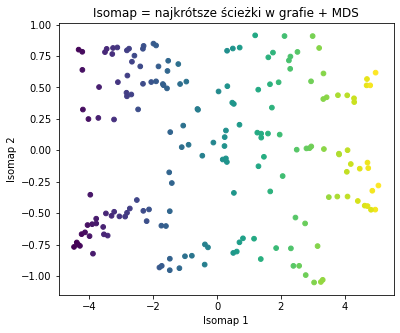

In [37]:
assert W_graph is not None and D_geodesic is not None, "Uzupełnij TODO 2."
n_components_graph, _ = connected_components(csr_matrix(W_graph), directed=False)
print("Liczba składowych grafu kNN:", n_components_graph)
assert n_components_graph == 1, "Graf jest rozspójniony. Zwiększ k_isomap."
assert np.isfinite(D_geodesic).all()

Y_isomap, eigenvalues_iso, _ = classical_mds(D_geodesic, n_components=2)
D_isomap_low = pairwise_distances(Y_isomap)

isomap_metrics = {
    "stress względem D_geodesic": normalized_stress(D_geodesic, D_isomap_low),
    "Spearman(D_geodesic, D_Y)": distance_spearman(D_geodesic, D_isomap_low),
    "Spearman(D_intrinsic, D_Y)": distance_spearman(D_intrinsic, D_isomap_low),
    "trustworthiness_k10": trustworthiness(X_curve, Y_isomap, n_neighbors=10),
}
display(pd.Series(isomap_metrics).round(3))

plt.figure(figsize=(6, 5))
plt.scatter(Y_isomap[:, 0], Y_isomap[:, 1], c=curve_position, s=22)
plt.title("Isomap = najkrótsze ścieżki w grafie + MDS")
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.show()

## 4. PCA i Laplacian Eigenmaps jako dwa punkty odniesienia

### PCA — liniowy punkt odniesienia

PCA nie zaczyna od macierzy sąsiedztwa. Szuka liniowych kierunków największej wariancji w $X$. Jest szybka i deterministyczna, ale nie „rozwija” silnie nieliniowej geometrii.

### Laplacian Eigenmaps — od $W$ do współrzędnych

Dla ważonej macierzy sąsiedztwa:

$$
W=[w_{ij}]
$$

tworzymy macierz stopni:

$$
D_{ii}^{deg}=\sum_j w_{ij}
$$

oraz laplasjan:

$$
L=D^{deg}-W.
$$

Metoda szuka $Y$, które minimalizuje:

$$
\sum_{i,j} w_{ij}\lVert y_i-y_j\rVert^2.
$$

Silnie połączone punkty powinny pozostać blisko. Rozwiązanie wynika z problemu własnego laplasjanu. Ta intuicja jest ważna dla zrozumienia metod grafowych, w tym inicjalizacji spektralnej używanej przez UMAP.

> Laplacian Eigenmaps nie jest UMAP-em. Wspólna jest idea: **lokalny ważony graf ma sterować położeniem punktów**.

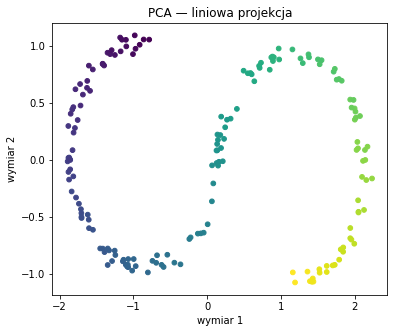

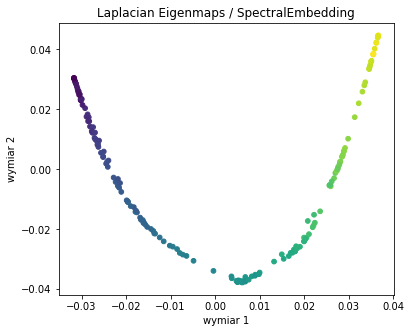

In [38]:
Y_pca = PCA(n_components=2).fit_transform(X_curve)
Y_spectral = SpectralEmbedding(
    n_components=2,
    n_neighbors=10,
    random_state=RANDOM_STATE
).fit_transform(X_curve)

for name, Y in [
    ("PCA — liniowa projekcja", Y_pca),
    ("Laplacian Eigenmaps / SpectralEmbedding", Y_spectral),
]:
    plt.figure(figsize=(6, 5))
    plt.scatter(Y[:, 0], Y[:, 1], c=curve_position, s=22)
    plt.title(name)
    plt.xlabel("wymiar 1")
    plt.ylabel("wymiar 2")
    plt.show()

# Część B — od odległości do podobieństw $P$ i $Q$

MDS porównuje $D^X$ i $D^Y$ bezpośrednio. t-SNE i UMAP najpierw zamieniają odległości na podobieństwa.

Najprostsze jądro Gaussa:

$$
s_{ij}=
\exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right).
$$

- mała odległość $\Rightarrow$ podobieństwo bliskie 1,
- duża odległość $\Rightarrow$ podobieństwo bliskie 0.

Jedna globalna wartość $\sigma$ bywa niewystarczająca, gdy gęstość danych jest różna. t-SNE i UMAP używają dlatego **lokalnej skali dla każdego punktu**.

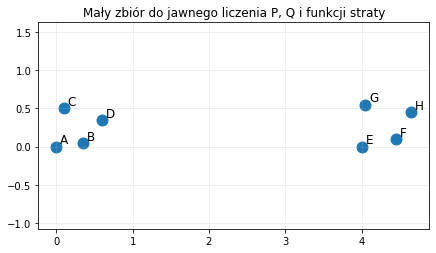

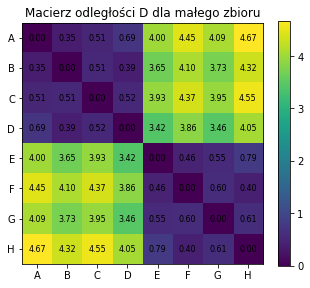

In [39]:
toy_labels = np.array(list("ABCDEFGH"))
X_toy = np.array([
    [0.00, 0.00],
    [0.35, 0.05],
    [0.10, 0.50],
    [0.60, 0.35],
    [4.00, 0.00],
    [4.45, 0.10],
    [4.05, 0.55],
    [4.65, 0.45],
])
D_toy = pairwise_distances(X_toy)

plt.figure(figsize=(7, 3.8))
plt.scatter(X_toy[:, 0], X_toy[:, 1], s=120)
for i, lab in enumerate(toy_labels):
    plt.text(X_toy[i, 0] + 0.05, X_toy[i, 1] + 0.04, lab, fontsize=12)
plt.axis("equal")
plt.grid(alpha=0.25)
plt.title("Mały zbiór do jawnego liczenia P, Q i funkcji straty")
plt.show()

show_matrix(D_toy, toy_labels, "Macierz odległości D dla małego zbioru")

# Część C — t-SNE

## 5. t-SNE: używane macierze to $P$ i $Q$

### $P$: podobieństwa z danych wejściowych

Dla każdego punktu $x_i$ definiujemy warunkowy rozkład sąsiadów:

$$
p_{j\mid i}
=
\frac{
\exp\left(-\frac{\lVert x_i-x_j\rVert^2}{2\sigma_i^2}\right)
}{
\sum_{k\neq i}
\exp\left(-\frac{\lVert x_i-x_k\rVert^2}{2\sigma_i^2}\right)
},
\qquad p_{i\mid i}=0.
$$

Każdy wiersz sumuje się do 1:

$$
\sum_{j\neq i}p_{j\mid i}=1.
$$

Wartość $\sigma_i$ jest dobierana osobno dla każdego punktu tak, aby entropia wiersza odpowiadała zadanej `perplexity`:

$$
\operatorname{Perp}(P_i)=
\exp\left(
-\sum_j p_{j\mid i}\log p_{j\mid i}
\right).
$$

`perplexity` można traktować jako przybliżoną efektywną liczbę istotnych sąsiadów.

Następnie t-SNE symetryzuje relację:

$$
p_{ij}
=
\frac{p_{j\mid i}+p_{i\mid j}}{2n}.
$$

Wynik:

$$
p_{ij}=p_{ji},\qquad p_{ii}=0,\qquad
\sum_{i\neq j}p_{ij}=1.
$$

Macierz $P$ jest więc **jednym globalnie znormalizowanym rozkładem prawdopodobieństwa nad uporządkowanymi parami punktów**.

### Techniczna funkcja: dobór jednego wiersza do zadanej perplexity

Poniższa funkcja wykonuje wyszukiwanie binarne parametru:

$$
\beta_i=\frac{1}{2\sigma_i^2}.
$$

Nie jest to główny `TODO`; ważniejsze jest złożenie macierzy $P$ z otrzymanych wierszy.

In [40]:
def tsne_row_probabilities(distances_squared, perplexity, tol=1e-6, max_iter=80):
    target_entropy = np.log(perplexity)
    beta = 1.0
    beta_min = -np.inf
    beta_max = np.inf

    for _ in range(max_iter):
        logits = -beta * distances_squared
        logits = logits - logits.max()  # stabilizacja numeryczna softmax
        weights = np.exp(logits)
        probs = weights / weights.sum()
        entropy = -np.sum(probs * np.log(np.clip(probs, EPS, None)))
        diff = entropy - target_entropy

        if abs(diff) < tol:
            break

        # Entropia za duża: rozkład jest za płaski, więc zwiększamy beta
        # i zmniejszamy sigma.
        if diff > 0:
            beta_min = beta
            beta = beta * 2 if np.isinf(beta_max) else (beta + beta_max) / 2
        else:
            beta_max = beta
            beta = beta / 2 if np.isinf(beta_min) else (beta + beta_min) / 2

    sigma = np.sqrt(1.0 / (2.0 * beta))
    return probs, sigma

### `TODO 3` — zbuduj $P$ dla t-SNE

### Pseudokod

```text
P_cond = macierz zer
dla każdego i:
    wybierz wszystkie indeksy poza i
    przekaż kwadraty odległości do funkcji tsne_row_probabilities
    wpisz wynik do wiersza i
P = (P_cond + P_cond.T) / (2*n)
wyzeruj przekątną
```

### Pseudokod bliski Pythonowi

```python
for i in range(n_toy):
    mask = np.arange(n_toy) != i
    probs, sigma_i = tsne_row_probabilities(
        D_toy[i, mask] ** 2,
        perplexity=perplexity_toy,
    )
    P_cond_tsne[i, mask] = probs
    sigma_tsne[i] = sigma_i

P_tsne = (P_cond_tsne + P_cond_tsne.T) / (2 * n_toy)
np.fill_diagonal(P_tsne, 0)
```


In [41]:
perplexity_toy = 2.5
n_toy = len(X_toy)
P_cond_tsne = np.zeros((n_toy, n_toy))
sigma_tsne = np.zeros(n_toy)

for i in range(n_toy):
    mask = np.arange(n_toy) != i
    probs, sigma_i = tsne_row_probabilities(
        D_toy[i, mask] ** 2,
        perplexity=perplexity_toy
    )
    P_cond_tsne[i, mask] = probs
    sigma_tsne[i] = sigma_i

P_tsne = (P_cond_tsne + P_cond_tsne.T) / (2 * n_toy)
np.fill_diagonal(P_tsne, 0)

,punkt,sigma_i,suma_wiersza_P_cond
0,A,0.3248,1.0
1,B,0.1970,1.0
2,C,0.0611,1.0
3,D,0.3111,1.0
4,E,0.3391,1.0
5,F,0.2369,1.0
6,G,0.1583,1.0
7,H,0.3760,1.0


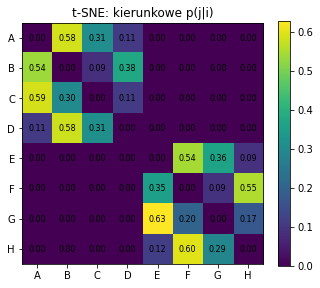

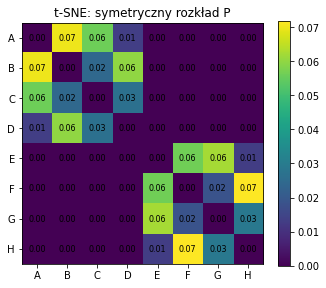

In [42]:
assert P_tsne is not None, "Uzupełnij TODO 3."
assert np.allclose(P_cond_tsne.sum(axis=1), 1)
assert np.allclose(P_tsne, P_tsne.T)
assert np.isclose(P_tsne.sum(), 1)

display(pd.DataFrame({
    "punkt": toy_labels,
    "sigma_i": sigma_tsne,
    "suma_wiersza_P_cond": P_cond_tsne.sum(axis=1),
}).round(4))

show_matrix(P_cond_tsne, toy_labels, "t-SNE: kierunkowe p(j|i)", vmin=0, vmax=P_cond_tsne.max())
show_matrix(P_tsne, toy_labels, "t-SNE: symetryczny rozkład P", vmin=0, vmax=P_tsne.max())

## 6. t-SNE: $Q(Y)$ i $KL(P\|Q)$

Dla aktualnych współrzędnych $Y$ t-SNE używa jądra rozkładu Studenta:

$$
q_{ij}
=
\frac{
(1+\lVert y_i-y_j\rVert^2)^{-1}
}{
\sum_{k\neq l}(1+\lVert y_k-y_l\rVert^2)^{-1}
},
\qquad q_{ii}=0.
$$

Tak jak $P$:

$$
\sum_{i\neq j}q_{ij}=1.
$$

Ciężki ogon rozkładu Studenta pozwala łatwiej umieścić niesąsiadujące punkty daleko i ogranicza **crowding problem**.

t-SNE minimalizuje:

$$
KL(P\|Q)
=
\sum_{i\neq j}
p_{ij}\log\frac{p_{ij}}{q_{ij}}.
$$

Interpretacja:

- duże $p_{ij}$, małe $q_{ij}$: zgubiono ważne sąsiedztwo — duża kara,
- małe $p_{ij}$, duże $q_{ij}$: utworzono fałszywe sąsiedztwo — kara istnieje, ale asymetria $KL(P\|Q)$ zwykle mocniej podkreśla zachowanie ważnych sąsiadów.

Jeżeli $P$ jest stałe:

$$
H(P,Q)=H(P)+KL(P\|Q),
$$

więc minimalizowanie KL i cross-entropy prowadzi do tego samego optimum względem $Q$.

### `TODO 4–5` — policz $Q$ i KL dla dwóch embeddingów

`Y_good` zachowuje dwie lokalne grupy. `Y_bad` miesza punkty obu grup.

### Pseudokod dla $Q$

```text
policz kwadraty odległości w Y
num = 1 / (1 + odległość_kwadrat)
wyzeruj przekątną
Q = num / suma(num)
```

### Pseudokod dla KL

```text
wybierz elementy, dla których P > 0
zsumuj P * log(P / Q)
```

### Pseudokod bliski Pythonowi

```python
# Q(Y)
D2 = pairwise_distances(Y, squared=True)
numerator = 1 / (1 + D2)
np.fill_diagonal(numerator, 0)
Q = numerator / numerator.sum()

# KL(P || Q)
mask = P > 0
value = np.sum(P[mask] * np.log(P[mask] / np.clip(Q[mask], EPS, None)))
```


In [43]:
Y_good = np.array([
    [0.00, 0.00], [0.35, 0.05], [0.10, 0.50], [0.60, 0.35],
    [3.00, 0.00], [3.45, 0.10], [3.05, 0.55], [3.65, 0.45],
])

Y_bad = np.array([
    [0.00, 0.00], [4.00, 0.00], [0.10, 0.40], [4.10, 0.40],
    [0.40, 0.00], [4.40, 0.00], [0.50, 0.40], [4.50, 0.40],
])

In [44]:
def tsne_Q(Y):
    D2 = pairwise_distances(Y, squared=True)
    numerator = 1.0 / (1.0 + D2)
    np.fill_diagonal(numerator, 0)
    Q = numerator / numerator.sum()
    return Q

def kl_divergence(P, Q):
    mask = P > 0
    value = np.sum(
        P[mask] * np.log(P[mask] / np.clip(Q[mask], EPS, None))
    )
    return value

,embedding,KL(P||Q)
0,Y_good,0.2685
1,Y_bad,1.5419


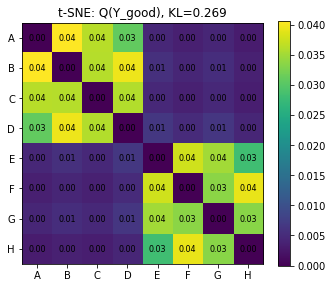

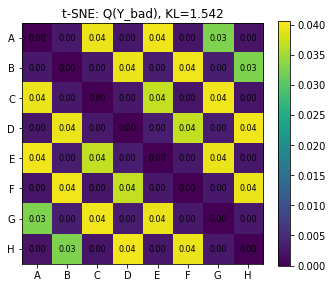

In [45]:
Q_good_tsne = tsne_Q(Y_good)
Q_bad_tsne = tsne_Q(Y_bad)

assert Q_good_tsne is not None and Q_bad_tsne is not None
assert np.isclose(Q_good_tsne.sum(), 1)
assert np.allclose(Q_good_tsne, Q_good_tsne.T)

kl_good = kl_divergence(P_tsne, Q_good_tsne)
kl_bad = kl_divergence(P_tsne, Q_bad_tsne)

display(pd.DataFrame({
    "embedding": ["Y_good", "Y_bad"],
    "KL(P||Q)": [kl_good, kl_bad],
}).round(4))
assert kl_good < kl_bad, "Sprawdź definicję Q lub KL — dobry embedding powinien mieć mniejszy błąd."

show_matrix(Q_good_tsne, toy_labels, f"t-SNE: Q(Y_good), KL={kl_good:.3f}", vmin=0, vmax=max(Q_good_tsne.max(), Q_bad_tsne.max()))
show_matrix(Q_bad_tsne, toy_labels, f"t-SNE: Q(Y_bad), KL={kl_bad:.3f}", vmin=0, vmax=max(Q_good_tsne.max(), Q_bad_tsne.max()))

## 7. Gotowa implementacja t-SNE

Po ręcznym zbudowaniu $P$, $Q$ i KL możemy użyć implementacji optymalizującej współrzędne $Y$.

Parametr `perplexity` steruje skalą lokalnego sąsiedztwa. Wynik jest stochastyczny, dlatego warto:

- ustawić `random_state`,
- porównać kilka wartości `perplexity`,
- nie interpretować dosłownie odległości pomiędzy dalekimi klastrami.

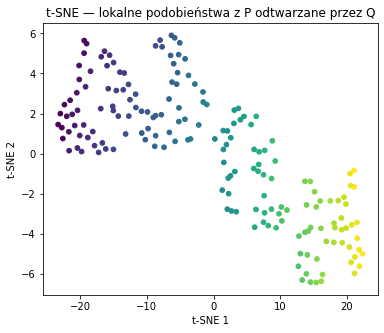

In [46]:
Y_tsne = TSNE(
    n_components=2,
    perplexity=25,
    init="pca",
    learning_rate="auto",
    #max_iter=500,
    method="exact",   # stabilne i wystarczająco szybkie dla 180 punktów
    n_jobs=1,
    random_state=RANDOM_STATE,
).fit_transform(X_curve)

plt.figure(figsize=(6, 5))
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], c=curve_position, s=22)
plt.title("t-SNE — lokalne podobieństwa z P odtwarzane przez Q")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

# Część D — UMAP

## 8. UMAP: $P$ jest rozmytym, ważonym grafem kNN

UMAP zaczyna jawnie od grafu $kNN$.

Dla punktu $i$:

- $N_k(i)$ — jego $k$ najbliższych sąsiadów,
- $\rho_i$ — odległość do najbliższego sensownego sąsiada,
- $\sigma_i$ — lokalna skala.

W uproszczeniu $\sigma_i$ dobieramy tak, aby:

$$
\sum_{j\in N_k(i)}
\exp\left(
-\frac{\max(0,d_{ij}-\rho_i)}{\sigma_i}
\right)
\approx \log_2(k).
$$

Kierunkowa siła krawędzi:

$$
p_{j\mid i}
=
\begin{cases}
\exp\left(
-\dfrac{\max(0,d_{ij}-\rho_i)}{\sigma_i}
\right),&j\in N_k(i),\\[6pt]
0,&j\notin N_k(i).
\end{cases}
$$

Następnie wykonujemy fuzzy union:

$$
p_{ij}
=
p_{j\mid i}+p_{i\mid j}
-p_{j\mid i}p_{i\mid j}.
$$

Otrzymujemy $P=[p_{ij}]$:

- symetryczną,
- rzadką,
- ważoną macierz sąsiedztwa,
- rozmyty graf lokalnych relacji.

Kluczowa różnica od t-SNE:

$$
\sum_{i<j}p_{ij}\neq 1
$$

w ogólnym przypadku. Elementy $P$ są siłami konkretnych krawędzi, a nie jednym globalnym rozkładem nad wszystkimi parami.

### Techniczna funkcja: dobór $\sigma_i$

Funkcja poniżej rozwiązuje równanie dla jednego wiersza grafu. W `TODO` wykorzystasz wynik do zbudowania macierzy kierunkowej i fuzzy union.

In [47]:
def solve_umap_sigma(neighbor_distances, rho, target, tol=1e-6, max_iter=80):
    low, high = 1e-4, 100.0

    for _ in range(max_iter):
        sigma = (low + high) / 2
        weights = np.exp(
            -np.maximum(0.0, neighbor_distances - rho) / sigma
        )
        current = weights.sum()

        if abs(current - target) < tol:
            return sigma
        if current > target:
            high = sigma
        else:
            low = sigma

    return (low + high) / 2

### `TODO 6` — zbuduj fuzzy graf $P$ UMAP

### Pseudokod

```text
dla każdego punktu i:
    wybierz k najbliższych sąsiadów
    rho_i = najmniejsza dodatnia odległość wśród nich
    sigma_i = solve_umap_sigma(...)
    dla każdego sąsiada j:
        P_dir[i,j] = exp(-max(0, d_ij-rho_i)/sigma_i)

P = P_dir + P_dir.T - P_dir * P_dir.T
wyzeruj przekątną
```

### Pseudokod bliski Pythonowi

```python
for i in range(n_toy):
    neighbor_ids = neighbors_umap[i]
    neighbor_distances = D_toy[i, neighbor_ids]
    rho_umap[i] = neighbor_distances[neighbor_distances > 0].min()
    sigma_umap[i] = solve_umap_sigma(
        neighbor_distances,
        rho=rho_umap[i],
        target=target_umap,
    )
    for j, distance in zip(neighbor_ids, neighbor_distances):
        P_dir_umap[i, j] = np.exp(
            -max(0.0, distance - rho_umap[i]) / sigma_umap[i]
        )

P_umap = P_dir_umap + P_dir_umap.T - P_dir_umap * P_dir_umap.T
np.fill_diagonal(P_umap, 0)
```


In [48]:
k_umap = 3
target_umap = np.log2(k_umap)
neighbors_umap = np.argsort(D_toy, axis=1)[:, 1:k_umap + 1]

rho_umap = np.zeros(n_toy)
sigma_umap = np.zeros(n_toy)
P_dir_umap = np.zeros((n_toy, n_toy))

for i in range(n_toy):
    neighbor_ids = neighbors_umap[i]
    neighbor_distances = D_toy[i, neighbor_ids]
    rho_umap[i] = neighbor_distances.min()
    sigma_umap[i] = solve_umap_sigma(
        neighbor_distances,
        rho=rho_umap[i],
        target=target_umap,
    )
    for j, distance in zip(neighbor_ids, neighbor_distances):
        P_dir_umap[i, j] = np.exp(
            -max(0.0, distance - rho_umap[i]) / sigma_umap[i]
        )

P_umap = (
    P_dir_umap
    + P_dir_umap.T
    - P_dir_umap * P_dir_umap.T
)
np.fill_diagonal(P_umap, 0)

,punkt,rho_i,sigma_i,suma_wag_kierunkowych
0,A,0.3536,0.1842,1.585
1,B,0.3536,0.0573,1.585
2,C,0.5099,0.0061,1.585
3,D,0.3905,0.1590,1.585
4,E,0.4610,0.1324,1.585
5,F,0.4031,0.0824,1.585
6,G,0.5523,0.0429,1.585
7,H,0.4031,0.2265,1.585


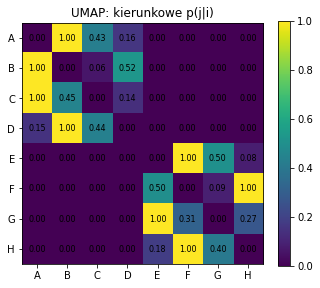

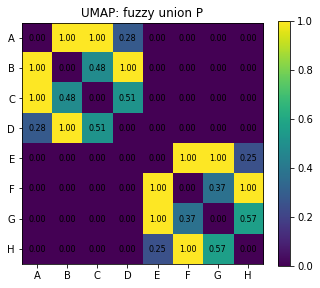

In [49]:
assert P_umap is not None, "Uzupełnij TODO 6."
assert np.allclose(P_umap, P_umap.T)
assert np.all((P_umap >= 0) & (P_umap <= 1))
assert not np.isclose(P_umap.sum(), 1), "UMAP P nie powinno być globalnie normalizowane."

display(pd.DataFrame({
    "punkt": toy_labels,
    "rho_i": rho_umap,
    "sigma_i": sigma_umap,
    "suma_wag_kierunkowych": P_dir_umap.sum(axis=1),
}).round(4))

show_matrix(P_dir_umap, toy_labels, "UMAP: kierunkowe p(j|i)", vmin=0, vmax=1)
show_matrix(P_umap, toy_labels, "UMAP: fuzzy union P", vmin=0, vmax=1)

## 9. UMAP: $Q(Y)$ i fuzzy cross-entropy

Dla punktów w embeddingu:

$$
q_{ij}
=
\frac{1}{
1+a\lVert y_i-y_j\rVert^{2b}
}.
$$

- $q_{ij}\approx 1$ — punkty są blisko,
- $q_{ij}\approx 0$ — punkty są daleko.

Parametry $a,b$ wynikają w implementacji z `min_dist` i `spread`. W małym przykładzie dydaktycznym użyjemy $a=b=1$.

UMAP porównuje dwie wersje grafu przez fuzzy cross-entropy:

$$
C(P,Q)
=
\sum_{i<j}
\left[
p_{ij}\log\frac{p_{ij}}{q_{ij}}
+
(1-p_{ij})\log\frac{1-p_{ij}}{1-q_{ij}}
\right].
$$

Ponieważ $P$ jest stałe, podczas optymalizacji $Y$ wystarczy minimalizować binary cross-entropy:

$$
L(Y)=
-\sum_{i<j}
\left[
p_{ij}\log q_{ij}
+
(1-p_{ij})\log(1-q_{ij})
\right].
$$

- $-p_{ij}\log q_{ij}$ — przyciąganie silnych krawędzi,
- $-(1-p_{ij})\log(1-q_{ij})$ — odpychanie par bez silnej krawędzi.

W praktycznym UMAP część odpychająca jest przybliżana przez **negative sampling**, zamiast sumowania wszystkich niekrawędzi.

### `TODO 7–8` — policz $Q$ UMAP i binary cross-entropy

W odróżnieniu od t-SNE nie normalizuj macierzy $Q$ przez jej sumę.

### Pseudokod bliski Pythonowi

```python
# Q(Y) UMAP — bez dzielenia przez sumę całej macierzy
D2 = pairwise_distances(Y, squared=True)
Q = 1 / (1 + a * (D2 ** b))
np.fill_diagonal(Q, 0)

# BCE: każdą nieuporządkowaną parę i < j liczymy raz
tri = np.triu_indices_from(P, k=1)
p = P[tri]
q = np.clip(Q[tri], EPS, 1 - EPS)
loss = -np.sum(p * np.log(q) + (1 - p) * np.log(1 - q))
```


In [50]:
def umap_Q(Y, a=1.0, b=1.0):
    D2 = pairwise_distances(Y, squared=True)
    Q = 1.0 / (1.0 + a * (D2 ** b))
    np.fill_diagonal(Q, 0)
    return Q

def fuzzy_binary_cross_entropy(P, Q):
    tri = np.triu_indices_from(P, k=1)
    p = P[tri]
    q = np.clip(Q[tri], EPS, 1 - EPS)
    loss = -np.sum(
        p * np.log(q)
        + (1 - p) * np.log(1 - q)
    )
    return loss

,embedding,fuzzy BCE
0,Y_good,8.0480
1,Y_bad,27.6024


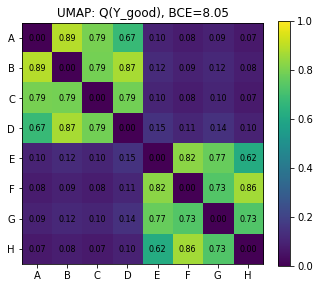

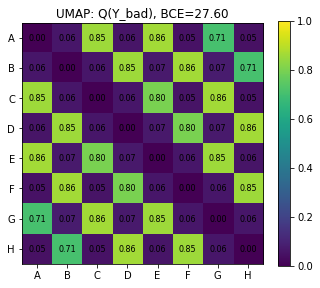

In [51]:
Q_good_umap = umap_Q(Y_good)
Q_bad_umap = umap_Q(Y_bad)

assert Q_good_umap is not None and Q_bad_umap is not None
assert np.allclose(Q_good_umap, Q_good_umap.T)
assert np.all((Q_good_umap >= 0) & (Q_good_umap <= 1))
assert not np.isclose(Q_good_umap.sum(), 1), "UMAP Q nie jest globalnie normalizowane."

ce_good = fuzzy_binary_cross_entropy(P_umap, Q_good_umap)
ce_bad = fuzzy_binary_cross_entropy(P_umap, Q_bad_umap)

display(pd.DataFrame({
    "embedding": ["Y_good", "Y_bad"],
    "fuzzy BCE": [ce_good, ce_bad],
}).round(4))
assert ce_good < ce_bad, "Sprawdź definicję Q lub BCE."

show_matrix(Q_good_umap, toy_labels, f"UMAP: Q(Y_good), BCE={ce_good:.2f}", vmin=0, vmax=1)
show_matrix(Q_bad_umap, toy_labels, f"UMAP: Q(Y_bad), BCE={ce_bad:.2f}", vmin=0, vmax=1)


## 10. Laboratorium optymalizacji: obserwuj, jak $Q(Y)$ zbliża się do $P$

W obu metodach macierz docelowa $P$ jest obliczana raz z danych wejściowych. Zmieniają się współrzędne $Y$, a wraz z nimi macierz $Q(Y)$.

$$
P\ \text{stałe},
\qquad
Y^{(0)},Y^{(1)},\ldots,
\qquad
Q\bigl(Y^{(0)}\bigr),Q\bigl(Y^{(1)}\bigr),\ldots
$$

Poniższa animacja pokazuje trzy obiekty jednocześnie:

1. target $P$,
2. aktualną macierz $Q(Y)$,
3. aktualne położenie punktów $Y$.

Można zmienić `METHOD_TO_ANIMATE`, krok uczenia i liczbę iteracji. To jest **wersja dydaktyczna**:

- dla t-SNE stosujemy pełny gradient na wszystkich parach,
- dla UMAP minimalizujemy pełną fuzzy BCE z $a=b=1$,
- produkcyjny UMAP używa m.in. negative sampling.

### Jak czytać animację?

- jasne pola w $P$ to relacje, które chcemy zachować,
- jasne pola w $Q$ to relacje, które aktualnie widzi embedding,
- spadek straty oznacza, że oba obrazy relacji stają się bardziej zgodne.


In [52]:

def tsne_loss_and_gradient(Y, P):
    Q = tsne_Q(Y)
    differences = Y[:, None, :] - Y[None, :, :]
    distances_squared = np.sum(differences ** 2, axis=2)

    coefficients = 4.0 * (P - Q) / (1.0 + distances_squared)
    np.fill_diagonal(coefficients, 0)
    gradient = np.sum(coefficients[:, :, None] * differences, axis=1)
    loss = kl_divergence(P, Q)
    return loss, gradient, Q


def umap_loss_and_gradient(Y, P):
    differences = Y[:, None, :] - Y[None, :, :]
    distances_squared = np.sum(differences ** 2, axis=2)
    Q = 1.0 / (1.0 + distances_squared)
    np.fill_diagonal(Q, 0)

    # Dla q=1/(1+r) pochodna BCE względem r ma postać (p-q)/r.
    coefficients = 2.0 * (P - Q) / np.maximum(distances_squared, 1e-3)
    np.fill_diagonal(coefficients, 0)
    gradient = np.sum(coefficients[:, :, None] * differences, axis=1)
    loss = fuzzy_binary_cross_entropy(P, Q)
    return loss, gradient, Q


def optimize_toy_embedding(
    P,
    method,
    n_steps,
    learning_rate,
    snapshot_every=10,
    momentum=0.8,
    random_state=7,
):
    rng = np.random.default_rng(random_state)
    initial_scale = 0.01 if method == "tsne" else 0.5
    Y = rng.normal(scale=initial_scale, size=(len(P), 2))
    velocity = np.zeros_like(Y)

    snapshots = []
    snapshot_losses = []

    for step in range(n_steps + 1):
        if method == "tsne":
            loss, gradient, _ = tsne_loss_and_gradient(Y, P)
        elif method == "umap":
            loss, gradient, _ = umap_loss_and_gradient(Y, P)
        else:
            raise ValueError("method musi być równe 'tsne' albo 'umap'")

        if step % snapshot_every == 0 or step == n_steps:
            snapshots.append(Y.copy())
            snapshot_losses.append(float(loss))

        if step < n_steps:
            velocity = momentum * velocity - learning_rate * gradient
            Y = Y + velocity
            Y = Y - Y.mean(axis=0, keepdims=True)

    return snapshots, snapshot_losses


def make_pq_animation(P, snapshots, losses, method, labels):
    if not PLOTLY_AVAILABLE:
        print("Do animacji potrzebny jest pakiet plotly.")
        return None

    q_function = tsne_Q if method == "tsne" else umap_Q
    q_matrices = [q_function(Y) for Y in snapshots]
    zmax_q = max(Q.max() for Q in q_matrices)
    zmax_p = P.max()

    all_coordinates = np.vstack(snapshots)
    margin = 0.10 * max(1.0, np.abs(all_coordinates).max())
    x_range = [all_coordinates[:, 0].min() - margin, all_coordinates[:, 0].max() + margin]
    y_range = [all_coordinates[:, 1].min() - margin, all_coordinates[:, 1].max() + margin]

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Target P", "Aktualne Q(Y)", "Aktualny embedding Y"),
        specs=[[{"type": "heatmap"}, {"type": "heatmap"}, {"type": "scatter"}]],
    )

    fig.add_trace(go.Heatmap(z=P, zmin=0, zmax=zmax_p, showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=q_matrices[0], zmin=0, zmax=zmax_q, showscale=False), row=1, col=2)
    fig.add_trace(
        go.Scatter(
            x=snapshots[0][:, 0], y=snapshots[0][:, 1],
            mode="markers+text", text=labels, textposition="top center",
        ),
        row=1, col=3,
    )

    frames = []
    for frame_id, (Y, Q, loss) in enumerate(zip(snapshots, q_matrices, losses)):
        frames.append(go.Frame(
            name=str(frame_id),
            data=[
                go.Heatmap(z=P, zmin=0, zmax=zmax_p, showscale=False),
                go.Heatmap(z=Q, zmin=0, zmax=zmax_q, showscale=False),
                go.Scatter(
                    x=Y[:, 0], y=Y[:, 1],
                    mode="markers+text", text=labels, textposition="top center",
                ),
            ],
            layout=go.Layout(title_text=f"{method.upper()} — klatka {frame_id}, strata={loss:.4f}"),
        ))

    fig.frames = frames
    slider_steps = [
        {
            "method": "animate",
            "args": [[frame.name], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}],
            "label": frame.name,
        }
        for frame in frames
    ]
    fig.update_layout(
        width=1150,
        height=430,
        title=f"Optymalizacja {method.upper()}: P pozostaje stałe, Q zmienia się razem z Y",
        sliders=[{"steps": slider_steps, "currentvalue": {"prefix": "klatka: "}}],
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {"label": "▶", "method": "animate", "args": [None, {"frame": {"duration": 300, "redraw": True}, "fromcurrent": True}]},
                {"label": "■", "method": "animate", "args": [[None], {"mode": "immediate", "frame": {"duration": 0, "redraw": False}}]},
            ],
        }],
    )
    fig.update_xaxes(range=x_range, row=1, col=3)
    fig.update_yaxes(range=y_range, scaleanchor="x3", scaleratio=1, row=1, col=3)
    return fig


In [60]:

# Zmień tę wartość na "umap", aby porównać przebieg obu optymalizacji.
METHOD_TO_ANIMATE = "tsne"

optimization_settings = {
    "tsne": {"P": P_tsne, "n_steps": 300, "learning_rate": 5.0, "snapshot_every": 10},
    "umap": {"P": P_umap, "n_steps": 400, "learning_rate": 0.05, "snapshot_every": 10},
}

optimization_results = {}
for method, settings in optimization_settings.items():
    snapshots, losses = optimize_toy_embedding(
        P=settings["P"],
        method=method,
        n_steps=settings["n_steps"],
        learning_rate=settings["learning_rate"],
        snapshot_every=settings["snapshot_every"],
    )
    optimization_results[method] = {"snapshots": snapshots, "losses": losses}

summary_optimization = pd.DataFrame([
    {
        "metoda": method,
        "strata_poczatkowa": result["losses"][0],
        "strata_koncowa": result["losses"][-1],
        "spadek": result["losses"][0] - result["losses"][-1],
    }
    for method, result in optimization_results.items()
])
display(summary_optimization.round(4))

selected = optimization_results[METHOD_TO_ANIMATE]
fig_optimization = make_pq_animation(
    P=optimization_settings[METHOD_TO_ANIMATE]["P"],
    snapshots=selected["snapshots"],
    losses=selected["losses"],
    method=METHOD_TO_ANIMATE,
    labels=toy_labels,
)
if fig_optimization is not None:
    fig_optimization.show()


,metoda,strata_poczatkowa,strata_koncowa,spadek
0,tsne,0.9955,0.0347,0.9608
1,umap,39.5391,5.4629,34.0762


## 10. t-SNE i UMAP — co jest wspólne?

Obie metody realizują ogólny schemat:

$$
X
\longrightarrow
\text{lokalne relacje }P
\longrightarrow
Y
\longrightarrow
Q(Y)
\longrightarrow
\min_Y \operatorname{Loss}(P,Q(Y)).
$$

W obu metodach:

- bliscy, ważni sąsiedzi są przyciągani,
- fałszywe sąsiedztwa wywołują odpychanie,
- lokalna skala jest dostosowywana osobno dla punktów,
- wynik zależy od parametrów i inicjalizacji,
- rozdzielone grupy pojawiają się, gdy pomiędzy nimi jest mało silnych relacji,
- metoda sama w sobie **nie nadaje etykiet klastrów**.

Nie należy mówić, że metody po prostu „maksymalnie rozdzielają klastry”. Trafniej:

> starają się zachować ważne lokalne relacje i jednocześnie uniknąć fałszywych relacji w 2D; separacja jest skutkiem tej optymalizacji.

## 11. t-SNE i UMAP — najważniejsze różnice

| Element | t-SNE | UMAP |
|---|---|---|
| Punkt startu | odległości wszystkich par lub ich przybliżenie | jawny graf $kNN$ |
| $P$ | globalny rozkład prawdopodobieństwa nad parami | ważony, rozmyty graf kNN |
| Lokalna skala | $\sigma_i$ dobrane przez `perplexity` | $\rho_i,\sigma_i$ w lokalnym grafie |
| Symetryzacja | $(p_{j|i}+p_{i|j})/(2n)$ | fuzzy union |
| Normalizacja $P$ | $\sum p_{ij}=1$ | brak globalnej normalizacji |
| $Q$ w 2D | Student-t i globalna normalizacja | niezależna siła $1/(1+a d^{2b})$ |
| Normalizacja $Q$ | $\sum q_{ij}=1$ | brak globalnej normalizacji |
| Strata | $KL(P\|Q)$ | fuzzy/binary cross-entropy |
| Obliczenia | przybliżenia Barnes–Hut/FFT | rzadki kNN + negative sampling |
| Typowy nacisk | bardzo czytelne lokalne grupy | lokalna struktura i często większa ciągłość |

### Które $P$, które $Q$?

- **t-SNE $P$:** rozkład podobieństw wyliczony z $X$,
- **t-SNE $Q$:** rozkład podobieństw wyliczony z aktualnego $Y$,
- **UMAP $P$:** fuzzy graf kNN wyliczony z $X$,
- **UMAP $Q$:** fuzzy graf wynikający z odległości w aktualnym $Y$.

W obu przypadkach $P$ jest targetem, a $Q(Y)$ zmienia się razem z embeddingiem.

## 12. KL divergence a cross-entropy w tych metodach

Dla znormalizowanych rozkładów:

$$
H(P,Q)=H(P)+KL(P\|Q).
$$

Gdy $P$ jest stałe, minimalizacja cross-entropy i KL względem $Q$ daje to samo optimum.

t-SNE używa jednak konkretnego kierunku:

$$
KL(P\|Q),
$$

który szczególnie mocno karze sytuację, gdy ważna para w $P$ ma za małe podobieństwo w $Q$.

UMAP traktuje każdą parę jak rozmytą zmienną Bernoulliego:

$$
p_{ij}\in[0,1],\qquad q_{ij}\in[0,1],
$$

dlatego pojawia się również jawny składnik:

$$
(1-p_{ij})\log(1-q_{ij}),
$$

odpowiedzialny za pary, które nie powinny tworzyć silnej krawędzi.

> KL divergence i cross-entropy nie są klasycznymi metrykami odległości. KL jest asymetryczna, a obie wielkości służą tu jako funkcje niedopasowania.

## 13. Gotowa implementacja UMAP — sekcja opcjonalna

Ręczne komórki powyżej pokazują najważniejsze obiekty matematyczne. Produkcyjny UMAP zawiera dodatkowe szczegóły: przybliżone wyszukiwanie sąsiadów, dobór parametrów krzywej, inicjalizację spektralną i stochastyczną optymalizację z negative sampling.

Komórka uruchomi bibliotekę tylko wtedy, gdy `umap-learn` jest zainstalowany.

In [61]:
try:
    import umap

    Y_umap = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        random_state=RANDOM_STATE,
    ).fit_transform(X_curve)

    plt.figure(figsize=(6, 5))
    plt.scatter(Y_umap[:, 0], Y_umap[:, 1], c=curve_position, s=22)
    plt.title("UMAP — gotowa implementacja")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()
except ImportError:
    Y_umap = None
    print(
        "Biblioteka umap-learn nie jest zainstalowana. "
        "Ręczne P, Q i fuzzy cross-entropy zostały policzone powyżej. "
        "Opcjonalna instalacja: pip install umap-learn"
    )

Biblioteka umap-learn nie jest zainstalowana. Ręczne P, Q i fuzzy cross-entropy zostały policzone powyżej. Opcjonalna instalacja: pip install umap-learn


## 14. Porównanie wyników — nie tylko „ładny obrazek”

Dwie proste diagnostyki:

- `trustworthiness(k)` — czy sąsiedzi widoczni w embeddingu rzeczywiście byli sąsiadami w $X$,
- korelacja rang odległości — na ile zachowano globalne uporządkowanie wszystkich odległości.

t-SNE i UMAP są projektowane przede wszystkim do lokalnych relacji, więc niska globalna korelacja nie musi oznaczać błędu.


## Dodatkowe: parametry zmieniają skalę lokalności

- większa `perplexity` w t-SNE uwzględnia szersze otoczenie,
- większe `n_neighbors` w UMAP buduje graf na szerszej skali,
- mniejsze `min_dist` pozwala tworzyć bardziej zwarte skupiska w embeddingu.

Nie istnieje jeden „prawidłowy” wykres. Stabilny wniosek powinien utrzymywać się dla kilku rozsądnych ustawień.


In [62]:

RUN_PARAMETER_SWEEP = False  # ustaw True po części obowiązkowej

if RUN_PARAMETER_SWEEP:
    for perplexity in [5, 15, 40]:
        Y_variant = TSNE(
            n_components=2,
            perplexity=perplexity,
            init="pca",
            learning_rate="auto",
            max_iter=500,
            random_state=RANDOM_STATE,
        ).fit_transform(X_curve)
        plt.figure(figsize=(6, 5))
        plt.scatter(Y_variant[:, 0], Y_variant[:, 1], c=curve_position, s=20)
        plt.title(f"t-SNE, perplexity={perplexity}")
        plt.show()

    try:
        import umap
        for n_neighbors, min_dist in [(5, 0.05), (15, 0.1), (40, 0.5)]:
            Y_variant = umap.UMAP(
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                random_state=RANDOM_STATE,
            ).fit_transform(X_curve)
            plt.figure(figsize=(6, 5))
            plt.scatter(Y_variant[:, 0], Y_variant[:, 1], c=curve_position, s=20)
            plt.title(f"UMAP, n_neighbors={n_neighbors}, min_dist={min_dist}")
            plt.show()
    except ImportError:
        print("Brak umap-learn — pomijam warianty UMAP.")
else:
    print("Skan parametrów jest wyłączony. Ustaw RUN_PARAMETER_SWEEP=True, aby go uruchomić.")


Skan parametrów jest wyłączony. Ustaw RUN_PARAMETER_SWEEP=True, aby go uruchomić.


In [63]:
embeddings = {
    "PCA": Y_pca,
    "MDS": Y_mds,
    "Isomap": Y_isomap,
    "Laplacian Eigenmaps": Y_spectral,
    "t-SNE": Y_tsne,
}
if Y_umap is not None:
    embeddings["UMAP"] = Y_umap

metric_rows = []
for name, Y in embeddings.items():
    D_low = pairwise_distances(Y)
    metric_rows.append({
        "metoda": name,
        "trustworthiness_k10": trustworthiness(
            X_curve, Y, n_neighbors=10
        ),
        "Spearman(D_X, D_Y)": distance_spearman(D_curve, D_low),
        "Spearman(D_intrinsic, D_Y)": distance_spearman(D_intrinsic, D_low),
    })

display(
    pd.DataFrame(metric_rows)
    .sort_values("trustworthiness_k10", ascending=False)
    .round(3)
)

,metoda,trustworthiness_k10,"Spearman(D_X, D_Y)","Spearman(D_intrinsic, D_Y)"
2,Isomap,0.997,0.908,0.736
4,t-SNE,0.997,0.891,0.682
3,Laplacian Eigenmaps,0.958,0.692,0.546
0,PCA,0.951,0.967,0.589
1,MDS,0.951,0.967,0.589



### Co powinno być widoczne na powierzchni S?

- **PCA i klasyczny MDS** dobrze zachowują część globalnych odległości euklidesowych, ale nie wiedzą, że powierzchnię należy „rozwinąć”.
- **Isomap** zastępuje skróty euklidesowe odległościami po grafie i dlatego powinien dobrze uporządkować kolory wzdłuż powierzchni.
- **Laplacian Eigenmaps, t-SNE i UMAP** mocno chronią lokalnych sąsiadów; mogą zniekształcić globalną skalę, ale zwykle zachowują ciągłość lokalną.

Dlatego tabela zawiera trzy różne diagnostyki:

1. `trustworthiness` — jakość lokalnych sąsiadów,
2. korelację z $D^X$ — zachowanie euklidesowych odległości wejściowych,
3. korelację z $D_{intrinsic}$ — zachowanie znanej, rozwiniętej geometrii powierzchni.

Jedna metoda nie musi być najlepsza we wszystkich trzech kryteriach.


## Dodatkowy kontrast: dwa księżyce ukryte w 12 wymiarach

Księżyce były już użyte do porównania k-means, DBSCAN i Spectral Clustering. Teraz wykorzystujemy ten sam kształt, ale **ukrywamy go w przestrzeni 12-wymiarowej**.

Z oryginalnych współrzędnych $(x,y)$ tworzymy m.in.:

$$
x^2,\quad y^2,\quad xy,\quad
\sin(\pi x),\quad \cos(\pi x),\quad
\sin(\pi y),\quad \cos(\pi y)
$$

oraz kilka wymiarów szumowych. Następnie standaryzujemy cechy.

Dzięki temu możemy zobaczyć różnicę pomiędzy:

- **PCA i MDS** — metodami bardziej globalnymi/liniowymi,
- **Isomap i Laplacian Eigenmaps** — metodami wykorzystującymi graf sąsiedztwa,
- **t-SNE i UMAP** — metodami dopasowującymi lokalne podobieństwa.

Ważne: kolor klas jest używany wyłącznie **po wykonaniu embeddingu**, do oceny wyniku. Metody nie otrzymują etykiet podczas dopasowania.

In [64]:
X_moons_2d, y_moons_hidden = make_moons(
    n_samples=240,
    noise=0.06,
    random_state=7,
)
x_moon = X_moons_2d[:, 0]
y_moon = X_moons_2d[:, 1]
rng_moon = np.random.default_rng(7)

X_moons_high = np.column_stack([
    x_moon,
    y_moon,
    x_moon ** 2,
    y_moon ** 2,
    x_moon * y_moon,
    np.sin(np.pi * x_moon),
    np.cos(np.pi * x_moon),
    np.sin(np.pi * y_moon),
    np.cos(np.pi * y_moon),
    rng_moon.normal(scale=0.20, size=len(x_moon)),
    rng_moon.normal(scale=0.20, size=len(x_moon)),
    rng_moon.normal(scale=0.20, size=len(x_moon)),
])
X_moons_high = StandardScaler().fit_transform(X_moons_high)
D_moons_high = pairwise_distances(X_moons_high)

print('Kształt danych wysokowymiarowych:', X_moons_high.shape)

Kształt danych wysokowymiarowych: (240, 12)


In [66]:
# PCA i klasyczny MDS.
Y_moon_pca = PCA(n_components=2).fit_transform(X_moons_high)
Y_moon_mds, _, _ = classical_mds(D_moons_high, n_components=2)

# Isomap budowany ręcznie: kNN -> odległości grafowe -> MDS.
k_moon_graph = 12
W_moon_graph = np.zeros_like(D_moons_high)
for i in range(len(D_moons_high)):
    neighbors = np.argsort(D_moons_high[i])[1:k_moon_graph + 1]
    W_moon_graph[i, neighbors] = D_moons_high[i, neighbors]
W_moon_graph = np.maximum(W_moon_graph, W_moon_graph.T)
D_moon_graph = shortest_path(csr_matrix(W_moon_graph), directed=False)
Y_moon_isomap, _, _ = classical_mds(D_moon_graph, n_components=2)

Y_moon_spectral = SpectralEmbedding(
    n_components=2,
    n_neighbors=12,
    random_state=RANDOM_STATE,
).fit_transform(X_moons_high)

Y_moon_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    #max_iter=600,
    method='exact',
    n_jobs=1,
    random_state=RANDOM_STATE,
).fit_transform(X_moons_high)

moon_embeddings = {
    'PCA': Y_moon_pca,
    'MDS': Y_moon_mds,
    'Isomap': Y_moon_isomap,
    'Laplacian Eigenmaps': Y_moon_spectral,
    't-SNE': Y_moon_tsne,
}

try:
    import umap
    moon_embeddings['UMAP'] = umap.UMAP(
        n_neighbors=15,
        min_dist=0.10,
        n_components=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ).fit_transform(X_moons_high)
except ImportError:
    print('Brak umap-learn — porównanie będzie wykonane bez UMAP.')

Brak umap-learn — porównanie będzie wykonane bez UMAP.


,metoda,trustworthiness_k10,czystosc_sasiadow_k10,silhouette_w_2D
3,Laplacian Eigenmaps,0.895,1.000,0.585
4,t-SNE,0.984,1.000,0.596
2,Isomap,0.913,0.998,0.525
0,PCA,0.945,0.889,0.318
1,MDS,0.945,0.889,0.318


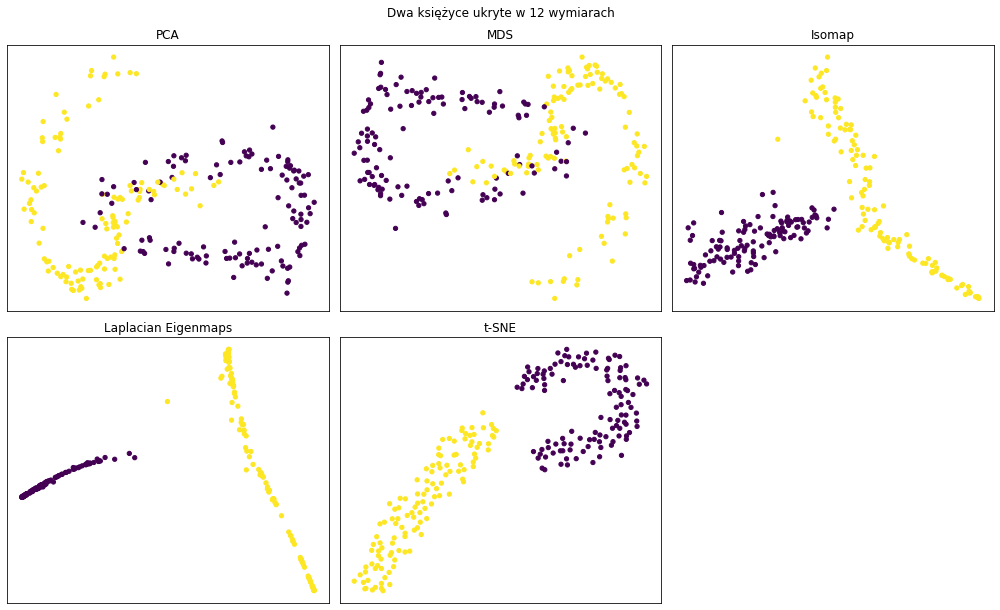

In [67]:
def local_neighbor_purity(Y, labels, k=10):
    neighbor_ids = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(
        return_distance=False
    )[:, 1:]
    return np.mean(labels[neighbor_ids] == labels[:, None])

moon_metrics = []
for method_name, Y in moon_embeddings.items():
    moon_metrics.append({
        'metoda': method_name,
        'trustworthiness_k10': trustworthiness(
            X_moons_high, Y, n_neighbors=10
        ),
        'czystosc_sasiadow_k10': local_neighbor_purity(
            Y, y_moons_hidden, k=10
        ),
        'silhouette_w_2D': silhouette_score(Y, y_moons_hidden),
    })

display(
    pd.DataFrame(moon_metrics)
    .sort_values('czystosc_sasiadow_k10', ascending=False)
    .round(3)
)

n_methods = len(moon_embeddings)
n_cols = 3
n_rows = int(np.ceil(n_methods / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.3 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, (method_name, Y) in zip(axes, moon_embeddings.items()):
    ax.scatter(Y[:, 0], Y[:, 1], c=y_moons_hidden, s=18)
    ax.set_title(method_name)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[n_methods:]:
    ax.axis('off')

plt.suptitle('Dwa księżyce ukryte w 12 wymiarach')
plt.tight_layout()
plt.show()

### Co powinno być widoczne?

- **PCA/MDS** mogą zachować sporą część globalnych odległości, ale nie muszą rozdzielić dwóch zakrzywionych grup.
- **Isomap** może dobrze odzyskać geometrię, jeśli graf $kNN$ nie tworzy skrótów pomiędzy księżycami.
- **Laplacian Eigenmaps, t-SNE i UMAP** silnie wykorzystują lokalne relacje, dlatego zwykle wyraźniej pokazują dwa łuki.
- Wysoki `silhouette` nie oznacza automatycznie, że globalne odległości są wierne.
- t-SNE i UMAP nie wykonały klasteryzacji: pokazały reprezentację, w której lokalne grupy stały się czytelne.

**Ćwiczenie interpretacyjne:** porównaj wynik z wcześniejszym DBSCAN. DBSCAN zwraca etykiety klastra, natomiast t-SNE/UMAP zwracają współrzędne embeddingu.

## 15. Jak interpretować embedding?

### MDS

Można ostrożniej interpretować globalne odległości, jeżeli stress jest mały. Zawsze warto sprawdzić:

- stress,
- korelację $D^X$ i $D^Y$,
- wykres odległości wejściowych względem odległości 2D.

### Isomap

Najpierw sprawdź:

- czy graf kNN jest spójny,
- czy $k$ nie jest zbyt małe,
- czy $k$ nie jest tak duże, że powstają skróty między odległymi fragmentami rozmaitości.

### t-SNE

Nie interpretuj dosłownie:

- odległości pomiędzy dalekimi klastrami,
- rozmiaru i pola klastrów,
- orientacji osi.

Sprawdź kilka `perplexity` i kilka ziaren losowych.

### UMAP

`n_neighbors` steruje skalą lokalności, a `min_dist` zwartością skupisk. UMAP może zachować więcej ciągłości niż t-SNE, ale nadal nie gwarantuje wiernych globalnych odległości.

### Dla obu metod

- standaryzuj cechy o różnych jednostkach,
- świadomie wybierz metrykę,
- nie używaj „ładności” wykresu jako jedynej oceny,
- embedding nie jest automatycznie klasteryzacją,
- etykiety klas najlepiej nakładać po wykonaniu nienadzorowanego embeddingu.

## 16. Koszt obliczeniowy

Pełna macierz odległości zawiera $n^2$ elementów:

$$
1\,000^2=1\,000\,000,
\qquad
10\,000^2=100\,000\,000.
$$

Konsekwencje:

- klasyczny MDS przechowuje pełne $D$ i wykonuje rozkład własny — nadaje się głównie do małych i średnich zbiorów,
- t-SNE korzysta z przybliżeń, np. Barnes–Hut lub FFT,
- UMAP po znalezieniu sąsiadów pracuje na rzadkim grafie około $O(nk)$,
- dla dużych danych nie tworzymy pełnej macierzy $D$, lecz używamy wyszukiwania najbliższych sąsiadów.

To praktyczny powód, dla którego graf $kNN$ jest tak ważnym obiektem.

# Podsumowanie

$$
\boxed{\text{MDS: }D^X\longrightarrow D^Y}
$$

$$
\boxed{\text{Isomap: }A_{kNN}\longrightarrow D^G\longrightarrow D^Y}
$$

$$
\boxed{\text{t-SNE: }P_{\text{rozkład}}\longrightarrow Q_{\text{rozkład}}(Y),\quad KL(P\|Q)}
$$

$$
\boxed{\text{UMAP: }P_{\text{fuzzy graf}}\longrightarrow Q_{\text{fuzzy graf}}(Y),\quad BCE}
$$

Najważniejsze zdanie:

> MDS odtwarza odległości, t-SNE odtwarza znormalizowany rozkład lokalnych podobieństw, a UMAP odtwarza rozmyty, ważony graf lokalnego sąsiedztwa.

## Pytania kontrolne

1. Dlaczego MDS używa $D^X$, ale nie potrzebuje $P$ i $Q$?
2. Gdzie w Isomap pojawia się $A_{kNN}$?
3. Dlaczego t-SNE ma $\sum p_{ij}=\sum q_{ij}=1$?
4. Dlaczego macierz $P$ UMAP nie musi sumować się do 1?
5. Która macierz pochodzi z $X$, a która z $Y$?
6. Jak `perplexity` i `n_neighbors` sterują skalą lokalności?
7. Dlaczego fałszywe sąsiedztwo jest widoczne w składniku $(1-p)\log(1-q)$ UMAP?
8. Dlaczego nie należy uważać t-SNE ani UMAP za algorytm klasteryzacji?